DATA VISUALIZATION

In [38]:
!pip install seaborn

In [39]:
import matplotlib.pyplot as plt
import seaborn as sns

In [40]:
import numpy as np
import pandas as pd
df=pd.read_csv("taxi10.csv")
df

,TripID,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,payment_type,fare_amount,...,PU_Borough_Queens,PU_Borough_Staten Island,PU_Borough_Unknown,PU_Borough_unknown,DO_Borough_Brooklyn,DO_Borough_Manhattan,DO_Borough_Queens,DO_Borough_Staten Island,DO_Borough_Unknown,DO_Borough_unknown
0,24870114,2,2017-03-25 08:55:43,2017-03-25 09:09:47,6,3.34,1,0.0,1,13.0,...,0,0,0,0,0,1,0,0,0,0
1,106203690,1,2017-12-15 07:26:56,2017-12-15 07:34:08,1,1.00,1,0.0,1,6.5,...,0,0,0,0,0,1,0,0,0,0
2,30841670,2,2017-04-15 23:32:20,2017-04-15 23:49:03,1,4.37,1,0.0,2,16.5,...,0,0,0,0,0,1,0,0,0,0
3,23345809,2,2017-03-25 20:34:11,2017-03-25 20:42:11,6,2.30,1,0.0,1,9.0,...,0,0,0,0,0,1,0,0,0,0
4,69059411,2,2017-08-15 17:41:06,2017-08-15 18:03:05,1,2.98,1,0.0,1,16.0,...,0,0,0,0,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13490,80420727,1,2017-09-24 18:14:04,2017-09-24 18:22:36,1,1.30,1,0.0,1,7.5,...,0,0,0,0,0,1,0,0,0,0
13491,44531431,2,2017-05-24 10:13:43,2017-05-24 10:31:34,1,2.79,1,NaN,2,13.5,...,1,0,0,0,0,0,1,0,0,0
13492,69393675,2,2017-08-16 20:17:35,2017-08-16 20:25:48,3,1.15,1,0.0,1,7.0,...,0,0,0,0,0,1,0,0,0,0
13493,81511935,2,2017-09-28 11:36:30,2017-09-28 11:49:58,5,1.93,1,0.0,1,10.5,...,0,0,0,0,0,1,0,0,0,0


In [41]:
df.columns

Index(['TripID', 'VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'payment_type', 'fare_amount', 'extra', 'mta_tax', 'tip_amount',
       'tolls_amount', 'improvement_surcharge', 'total_amount',
       'trip_duration_minutes', 'LocationID_x', 'DO_Zone', 'PU_Zone',
       'PU_Zone_freq', 'DO_Zone_freq', 'PU_Borough_Brooklyn', 'PU_Borough_EWR',
       'PU_Borough_Manhattan', 'PU_Borough_Queens', 'PU_Borough_Staten Island',
       'PU_Borough_Unknown', 'PU_Borough_unknown', 'DO_Borough_Brooklyn',
       'DO_Borough_Manhattan', 'DO_Borough_Queens', 'DO_Borough_Staten Island',
       'DO_Borough_Unknown', 'DO_Borough_unknown'],
      dtype='object')

1. TRIP DURATION DISTRIBUTION (HISTOGRAM)

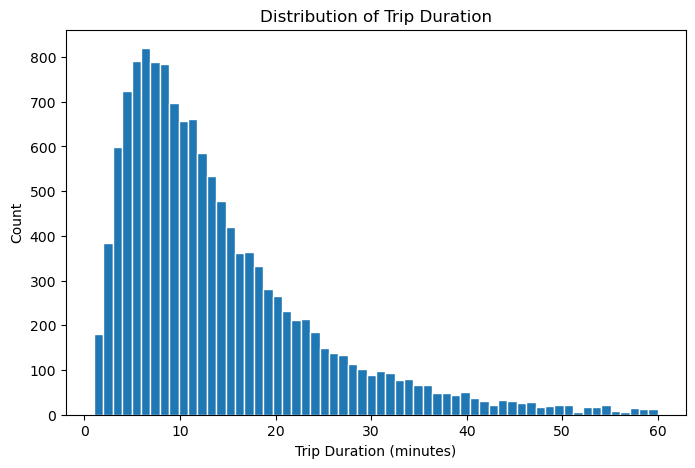

In [42]:
df[df['trip_duration_minutes'] <= 60]['trip_duration_minutes'] \
    .plot(kind='hist', bins=60, edgecolor='white', figsize=(8,5),
          title="Distribution of Trip Duration")

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Count")
plt.show()

From the plot,we can observe that
 
-->Most of the taxi trips are short in duration,mainly concentrated between 5-10 minutes.

-->The highest frquency occurs around 8-10 minutes,indicating that the majority of the trips falls within this range. 


2. TRIP DISTANCE DISTRIBUTION (HISTOGRAM)

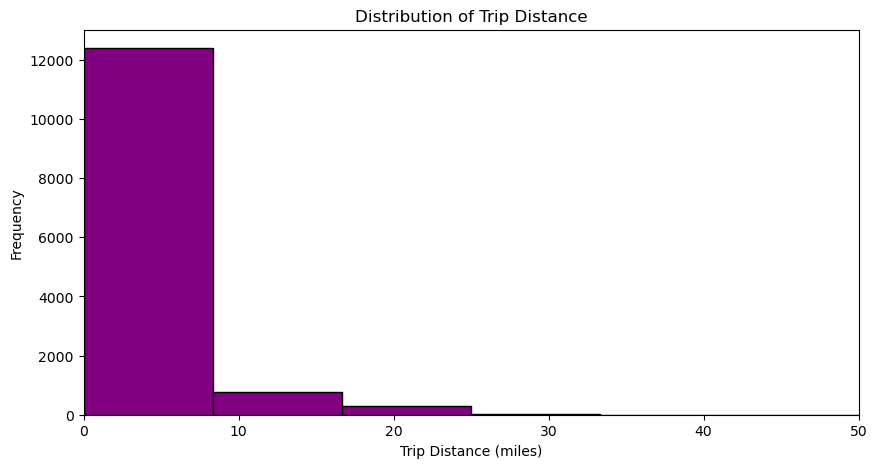

In [43]:
df[df['trip_distance'] <= 500]['trip_distance'] \
    .plot(kind='hist', bins=60, figsize=(10,5),
          title="Distribution of Trip Distance",color='purple',edgecolor="black")

plt.xlim(0,50)
plt.xlabel("Trip Distance (miles)")
plt.ylabel("Frequency")
plt.show()

From the graph,we can observe that:

1.Most trips are below 5 miles,showing that taxi rides are mainly used for short-distance tavel.

2.Long distances trips are very rare indicating that occasional longer journeys such as airport or inter city trips

3. FARE AMOUNT DISTRIBUTION (HISTOGRAM)

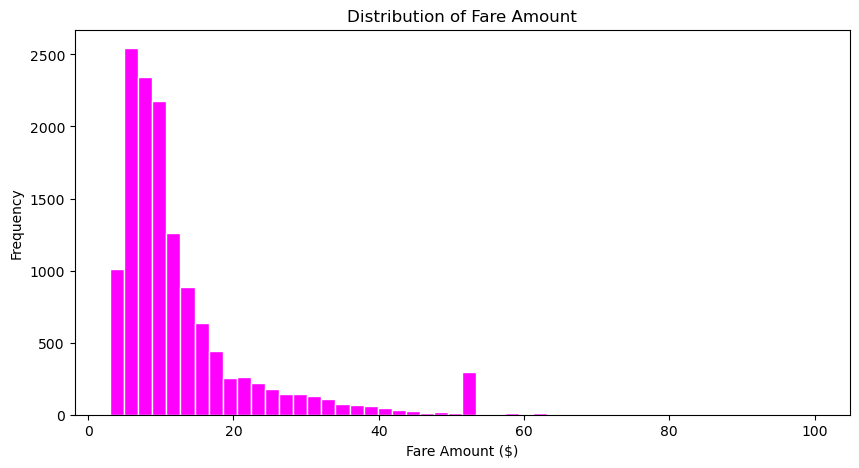

In [44]:
df[df['fare_amount'] <= 100]['fare_amount'] \
    .plot(kind='hist', bins=50, figsize=(10,5),
          title="Distribution of Fare Amount",color="magenta",edgecolor="white")

plt.xlabel("Fare Amount ($)")
plt.ylabel("Frequency")
plt.show()

From the graph,we can observe that

1.Most fares fall in the lower price range,showing that the majority of trips are affordable short rides

2.High fare values are relatively rare,representing long distance rides are having high fares.

4. PASSENGER COUNT DISTRIBUTION (BARCHART)

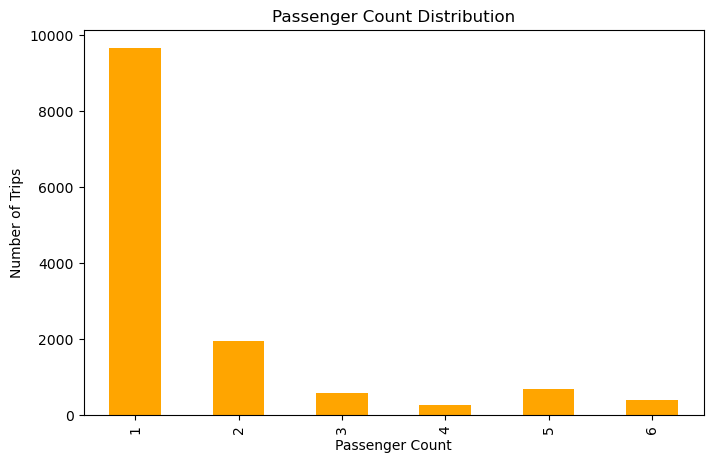

In [45]:
pc_counts = df['passenger_count'].value_counts().sort_index()

pc_counts.plot(kind='bar', figsize=(8,5),
               title="Passenger Count Distribution",color="orange")

plt.xlabel("Passenger Count")
plt.ylabel("Number of Trips")
plt.show()

From the graph,we can observe that 

1.The bar chart shows that most taxi rides involves 1 or 2 passengers,indicating that solo and small-group trvael dominates.

2.Trips with higher passenger counts are significantly less frequent.

5. PAYMENT TYPE DISTRIBUTION (BAR GRAPH)

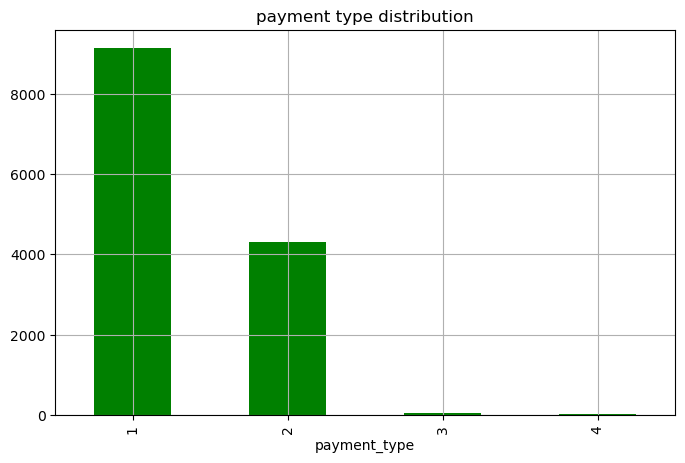

In [46]:
plt.figure(figsize=(8,5))
df['payment_type'].value_counts().plot(kind='bar',color='green')
plt.title("payment type distribution")
plt.grid()
plt.show()

6. TRIP DISTANCE VS FARE (SCATTER PLOT)

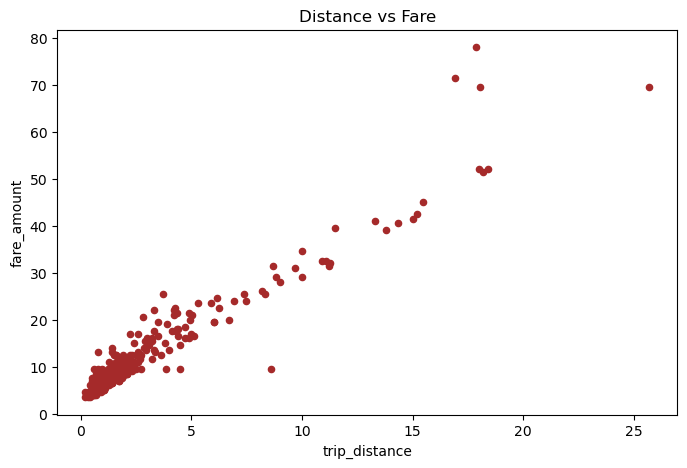

In [47]:
df.head(250).plot(
    kind='scatter',
    x='trip_distance',
    y='fare_amount',
    figsize=(8,5),
    color="brown",
    title="Distance vs Fare"
)

plt.show()

From the graph,we can observe that

1.The scatter plot between the trip distance and fare shows a positive linear relationship.

2.As distance increases,fare increases and also we can observe that most trips are short distance trips.

7. TRIP DURATION VS TOTAL AMOUNT (BUBBLE PLOT)

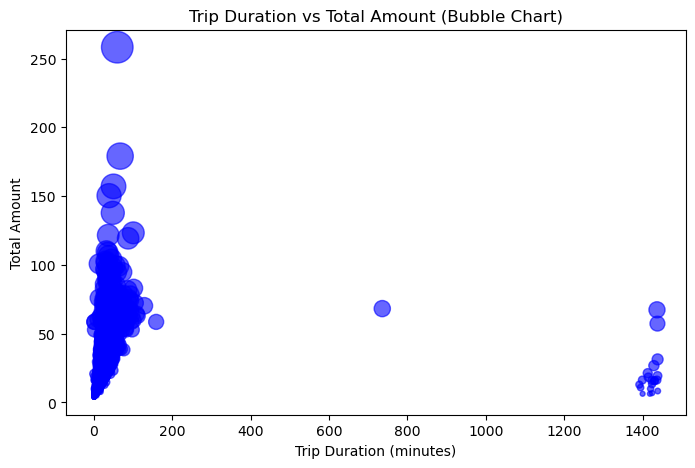

In [48]:
df.plot(
    kind='scatter',
    x='trip_duration_minutes',
    y='total_amount',
    s=df['total_amount']*2,
    color='blue',
    alpha=0.6,
    figsize=(8,5),
    title="Trip Duration vs Total Amount (Bubble Chart)"
)

plt.xlabel("Trip Duration (minutes)")
plt.ylabel("Total Amount")

plt.show()

8. PASSENGER COUNT VS FARE

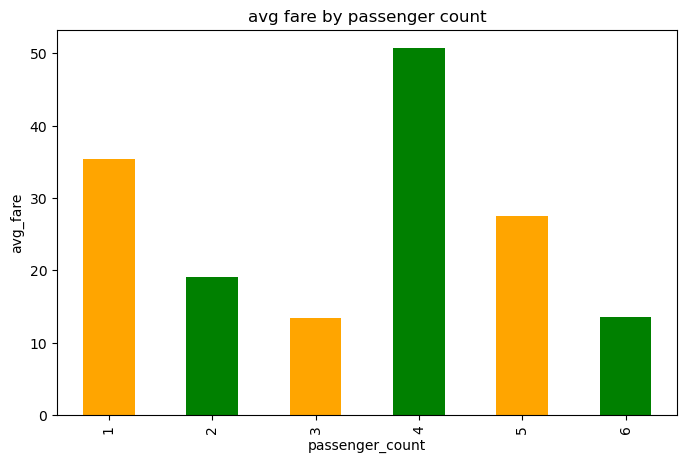

In [49]:
avg_fare=df.groupby('passenger_count')['fare_amount'].mean()
plt.figure(figsize=(8,5))
avg_fare.plot(kind='bar',color=['orange','green'])
plt.xlabel("passenger_count")
plt.ylabel("avg_fare")
plt.title("avg fare by passenger count")
plt.show()

From the graph,we can observe that

The fare does not significantly change with the number of passengers,indicating that pricing is mainly based on the distance and duration
 
rather than passenger count.

9. FARE AMOUNT (BOX PLOT)

In [50]:
Q1 = df['fare_amount'].quantile(0.25)
Q3 = df['fare_amount'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_clean1 = df[(df['fare_amount'] >= lower_limit) & 
              (df['fare_amount'] <= upper_limit)]

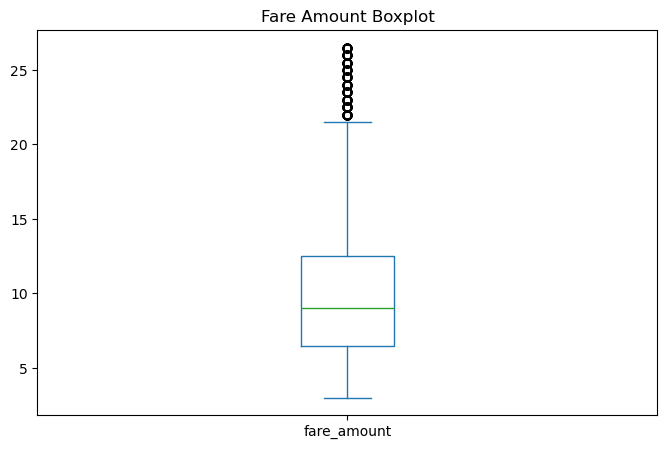

In [51]:
df_clean1['fare_amount'].plot(
    kind='box',
    figsize=(8,5),
    title="Fare Amount Boxplot"
)

plt.show()

Clear insights:

1.Most taxi fares lie between 3-15 rupees

2.Majority of trips are short distance rides.

3.Few trips have very high fare(80-150+rupees) and those are the outliers here which are represented using circles

10. TRIP DURATION (BOX PLOT)

In [52]:
Q1 = df['trip_duration_minutes'].quantile(0.25)
Q3 = df['trip_duration_minutes'].quantile(0.75)
IQR = Q3 - Q1
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR
df_clean = df[(df['trip_duration_minutes'] >= lower_limit) & 
              (df['trip_duration_minutes'] <= upper_limit)]

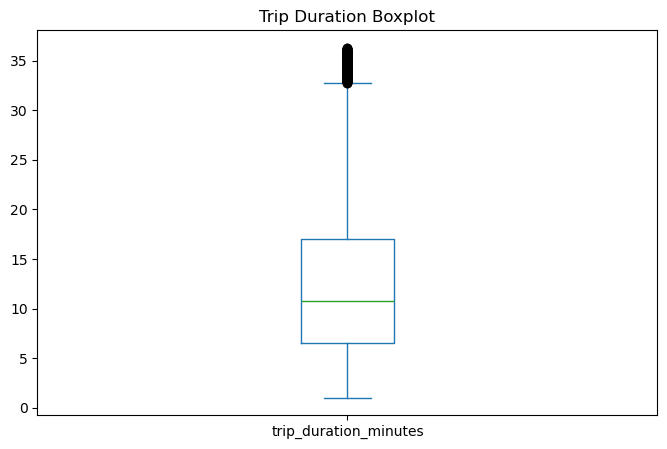

In [53]:
df_clean['trip_duration_minutes'].plot(
    kind='box',
    figsize=(8,5),
    title="Trip Duration Boxplot"
)

plt.show()

From the graph,we conclude that

1.Most taxi trips are short in duration.

2.The highest frequency of trips occurs between 5-15 minutes.

From the graph we observed that

At particular dates how the trip durations vary based on traffic conditions or travel distances

11. FARE TREND (LINE PLOT)

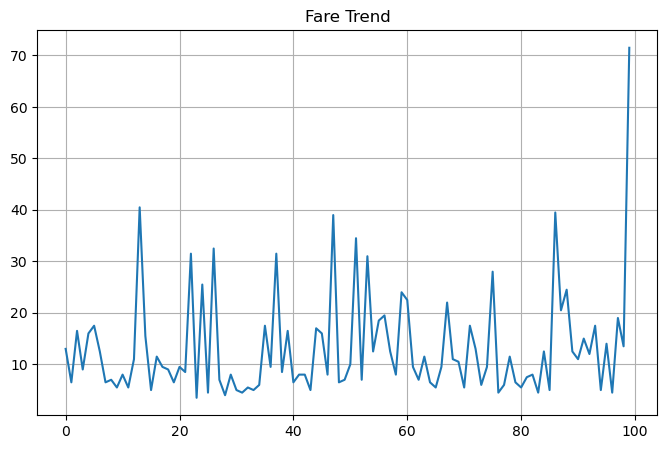

In [54]:
df['fare_amount'].head(100).plot(
    kind='line',
    figsize=(8,5),
    title="Fare Trend"
)
plt.grid()
plt.show()

12. RELATION BETWEEN AVG FARE AND DAY OF THE WEEK (LINE PLOT)

In [55]:
print(df['tpep_pickup_datetime'].dtype)
df['tpep_pickup_datetime']=pd.to_datetime(df['tpep_pickup_datetime'])
print(df['tpep_pickup_datetime'].dtype)

object
datetime64[ns]


In [56]:
df['day_name'] = df['tpep_pickup_datetime'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday',
             'Friday', 'Saturday', 'Sunday']
df['day_name'] = pd.Categorical(df['day_name'],
                                 categories=day_order,
                                 ordered=True)
day_fare = df.groupby('day_name')['fare_amount'].mean()


/tmp/ipykernel_4450/3868038333.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  day_fare = df.groupby('day_name')['fare_amount'].mean()


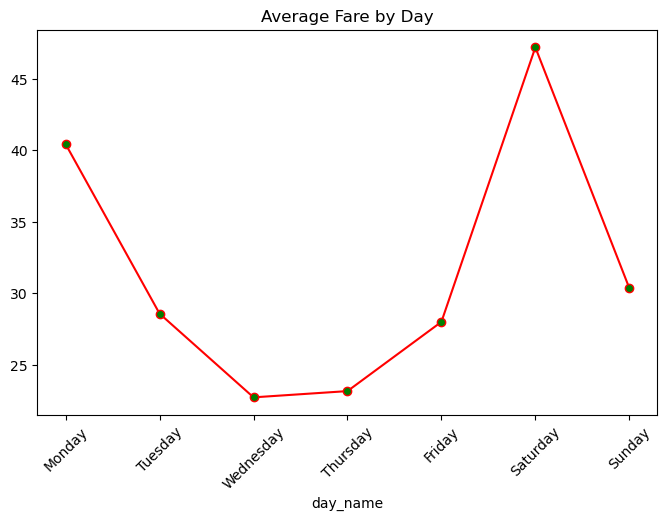

In [57]:
day_fare.plot(
    kind='line',
    color='red',
    marker='o',
    mfc='green',
    figsize=(8,5),
    title="Average Fare by Day"
)

plt.xticks(rotation=45)
plt.show()

We observed that

1.Certain days have higher average fares,indicating higher demand or longer trips

2.For other days having lower average fares may indicate that shorter trips or less demand.

3.The graph clearly shows that day of the week influences fare amount,and analysing time based data.

13. PAYMENT TYPE (PIE CHART)

In [58]:
payment_mapping = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute",
    5: "Unknown",
    6: "Voided Trip"
}

df['payment_type_name'] = df['payment_type'].map(payment_mapping)

In [59]:
df['payment_type'].dtype

dtype('int64')

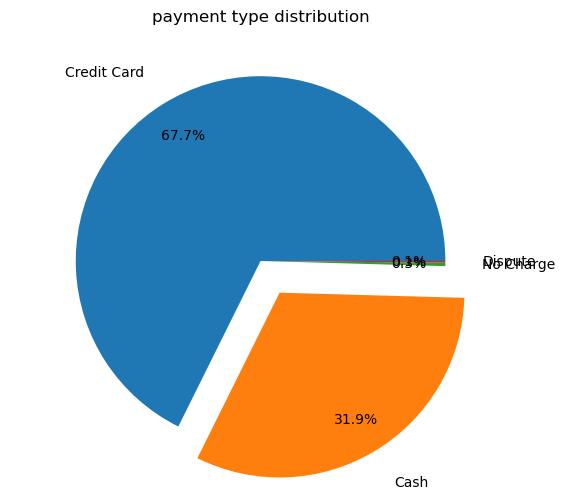

In [60]:
explode=[0,0.2,0,0]
plt.figure(figsize=(6,6))
df['payment_type_name'].value_counts().plot(kind='pie',autopct=lambda p:f'{p:.1f}%',explode=explode,labeldistance=1.2,pctdistance=0.8)
plt.title("payment type distribution")
plt.ylabel(" ")
plt.show()

From the graph,we observe that
 
 1.The dataset shows that customers mostly use card payments,indicating a strong shift towards digital transcations

 2.Cash payments are still remain important,dispute and no-charge cases are minimal and do not significantly affect the overall revenue

14. PAYMENT TYPE VS HOUR (STACKED BAR GRAPH)

In [61]:
df['hour'] = df['tpep_pickup_datetime'].dt.hour

stack_data = df.groupby(['hour','payment_type']).size().unstack().fillna(0)


<function matplotlib.pyplot.show(close=None, block=None)>

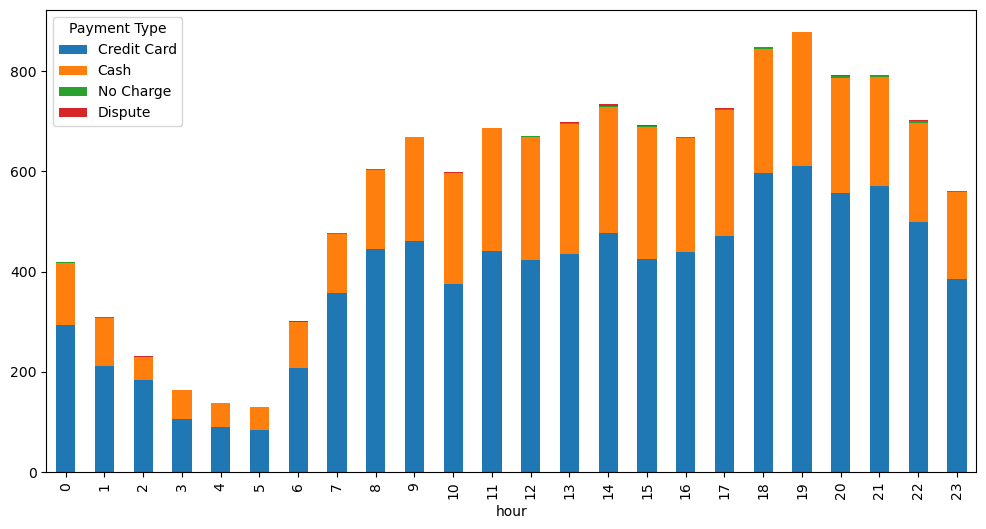

In [62]:
labels = {
    1: 'Credit Card',
    2: 'Cash',
    3: 'No Charge',
    4: 'Dispute',
    5: 'Unknown',
    6: 'Voided Trip'
}

stack_data.rename(columns=labels, inplace=True)

stack_data.plot(kind='bar', stacked=True, figsize=(12,6))
plt.legend(title="Payment Type")
plt.show

Graph reveals that:

1.Credit card payments dominate across almost all hours,escpecially during peak travel periods.

2.Cash payments form a smaller proportion,with relatively higher usage during early morning and late-night hours

15. TRIP VS HOUR(LINE PLOT)

In [63]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour

trips_per_hour = df['pickup_hour'].value_counts().sort_index()


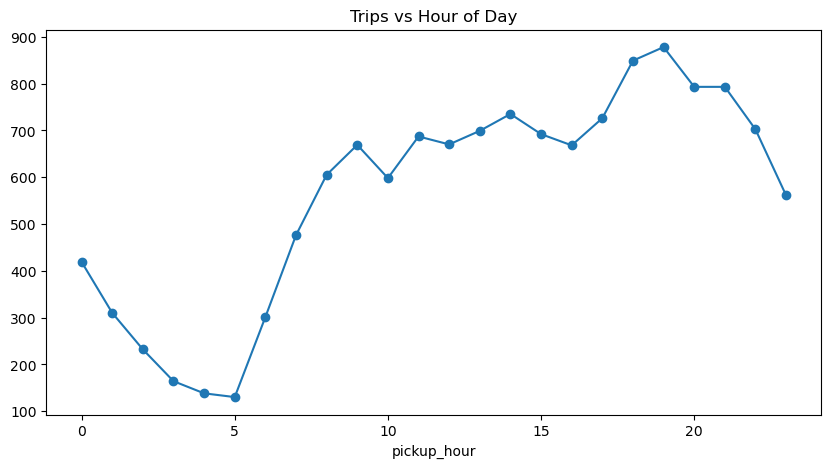

In [64]:
trips_per_hour.plot(
    kind='line',
    marker='o',
    figsize=(10,5),
    title="Trips vs Hour of Day"
)

plt.show()

Taxi demand is highest during evening rush hours and lowest in early morning hours.

16. TOP 10 PICKUP ZONES (BAR PLOT)

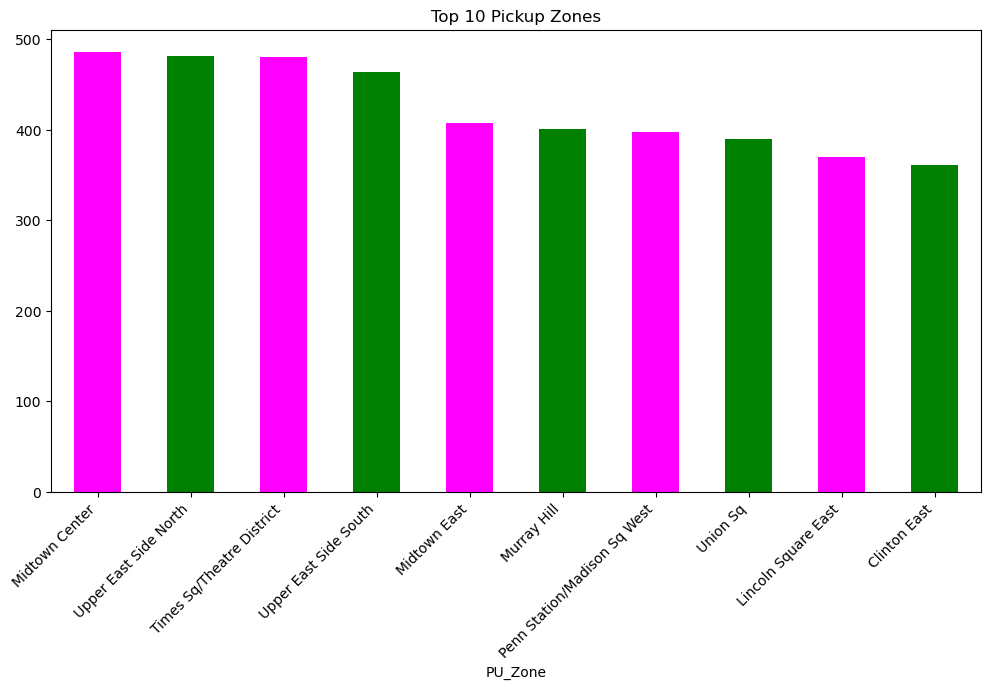

In [65]:
top10_pickup = df['PU_Zone'].value_counts().head(10)

top10_pickup.plot(
    kind='bar',
    figsize=(12,6),
    color=['magenta','green'],
    title="Top 10 Pickup Zones"
)

plt.xticks(rotation=45,ha="right")
plt.show()

From the graph,we conclude that

Taxi services should allocate more vehicles in these top-demand zones for better efficiency,they are

    Midtown center
    Upper East Side North
    Times sq/Theatre District
    Upper East Side South

17. AVERAGE FARE VS BOROUGH (BAR PLOT)

In [66]:
borough_cols = [col for col in df.columns if col.startswith('PU_Borough_')]
avg_fare = {}
for col in borough_cols:
    avg_fare[col.replace('borough_', '')] = df.loc[df[col] == 1, 'fare_amount'].mean()
avg_fare_series = pd.Series(avg_fare)


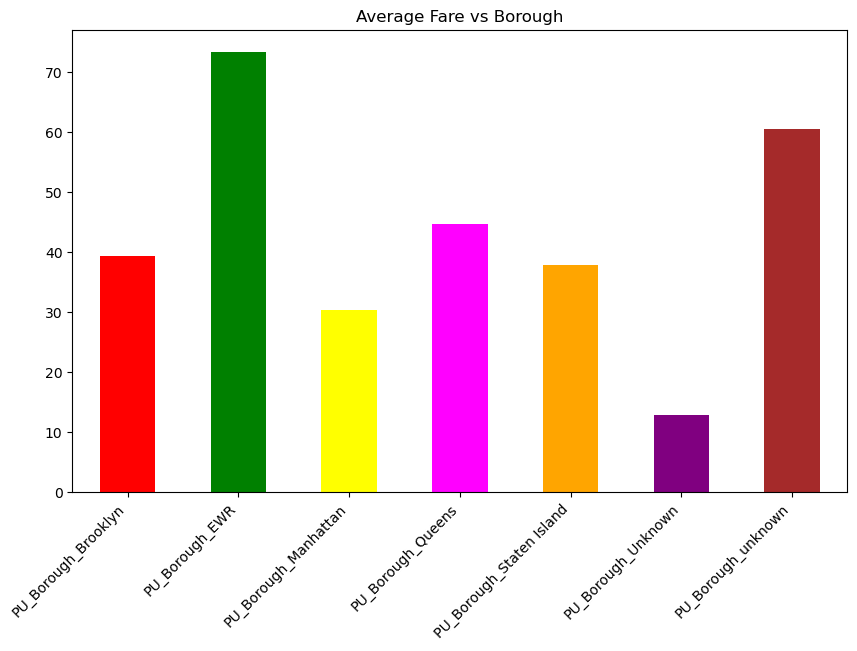

In [67]:
avg_fare_series.plot(
    kind='bar',
    figsize=(10,6),
    color=['red','green','yellow','magenta','orange','purple','brown'],
    title="Average Fare vs Borough",
)

plt.xticks(rotation=45,ha="right")
plt.show()

From the graph,we conclude that

1. Highest Average Fare: Airport/Long-Distance Areas

    Borough like EWR (Airport area) shows highest average fare.

    Indicates long-distance rides->higher fare.

2. Moderate Fare: Queens

    Likely includes airport trips (JFK).

    Mid-to-high fare values.

3. Lower Fare: Manhattan

    Possibly due to shorter urban trips.

4. Very Low Fare: Unknown Category

    Might include short trips or data anomalies.

18. DISTRIBUTION OF PAYMENT TYPES (WAFFLE CHART)

In [68]:
!pip install pywaffle

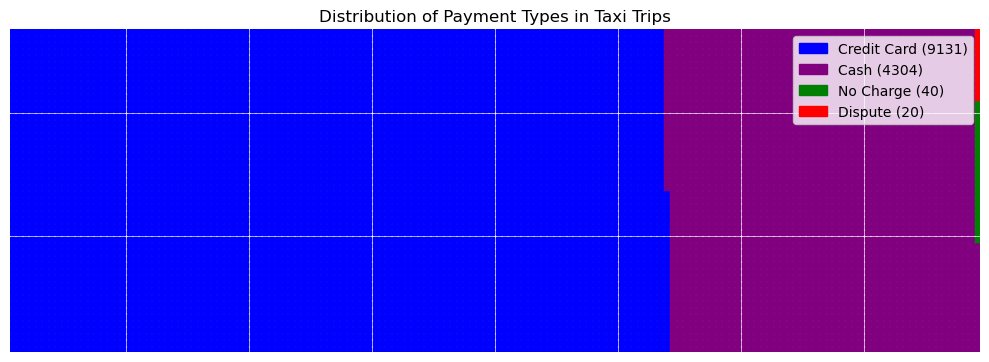

In [69]:
from pywaffle import Waffle
import matplotlib.pyplot as plt
payment_labels = {
    1: "Credit Card",
    2: "Cash",
    3: "No Charge",
    4: "Dispute"
}

payment_counts = df['payment_type'].value_counts()

fig = plt.figure(
    FigureClass=Waffle,
    rows=50,
    columns=150,
    values=payment_counts,
    labels=[f"{payment_labels[k]} ({v})" for k, v in payment_counts.items()],
    colors=["blue", "purple", "green", "red"], 
    figsize=(10,6)
)

plt.title("Distribution of Payment Types in Taxi Trips")
plt.show()

From this graph we conclude:

1. Taxi companies should prioritize:

        Digital payment infrastructure

        Card machine maintenance

2. Cash handling still required but less dominant

3. Very low disputes indicate strong trust in system

19. DAY VS HOUR (HEATMAP)

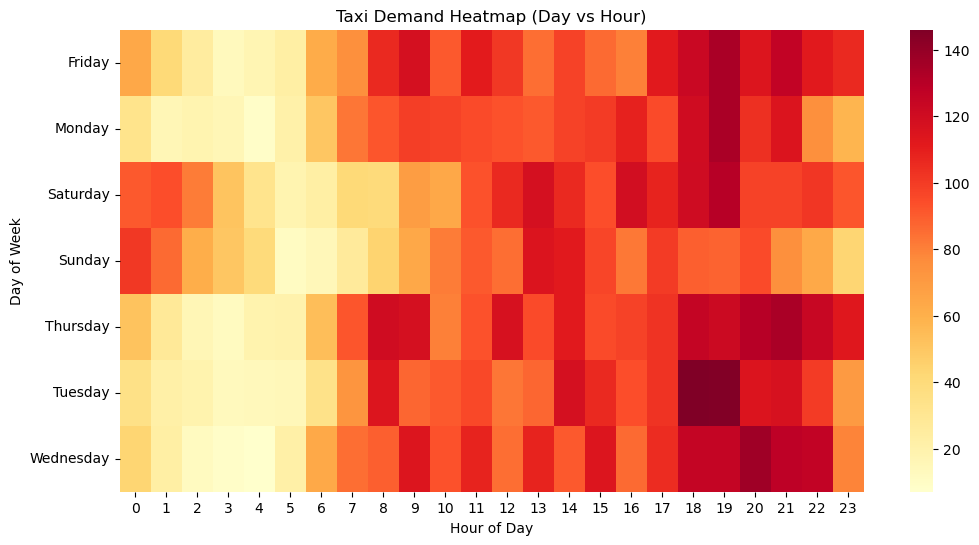

In [70]:
df['pickup_hour'] = df['tpep_pickup_datetime'].dt.hour
df['pickup_day'] = df['tpep_pickup_datetime'].dt.day_name()
heatmap_data = df.pivot_table(
    index='pickup_day',
    columns='pickup_hour',
    values='fare_amount',
    aggfunc='count'
)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

sns.heatmap(
    heatmap_data,
    cmap="YlOrRd",
    annot=False
)

plt.title("Taxi Demand Heatmap (Day vs Hour)")
plt.xlabel("Hour of Day")
plt.ylabel("Day of Week")

plt.show()

From the graph we can conclude very useful insights,they are

1.On week days(MONDAY-FRIDAY)there is a highest demand for taxi rides during 

                7AM - 10AM(Rush to attend the schools and to reach the offices)
                5PM - 9PM(Due to offices and schools closing time)

Hence taxi companies should deploy more drivers at that period of time

2.On weekend there should be more number of employees at night time mainly on friday night.

3.Early morning needs fewer drivers as there is no much requirement of taxi rides.


20. Pickup Zone representation (WORDCLOUD)

In [71]:
!pip install wordcloud

(np.float64(-0.5), np.float64(799.5), np.float64(399.5), np.float64(-0.5))

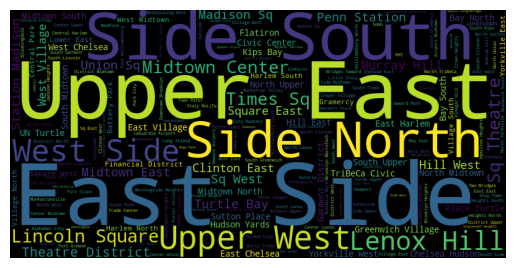

In [72]:
from wordcloud import WordCloud

text = " ".join(df['PU_Zone'])

wordcloud = WordCloud(width=800,height=400).generate(text)

plt.imshow(wordcloud)
plt.axis('off')

From the graph,we observed that

1.The word cloud visualization represents the frequency of taxi pickup in different zones.

2.Words that appear larger and bolder indicate zones with higher pickup frequency,
   while smaller words represent zones with fewer pickups.

21. REPRESENTING PICKUP ZONE (WORD CLOUD)

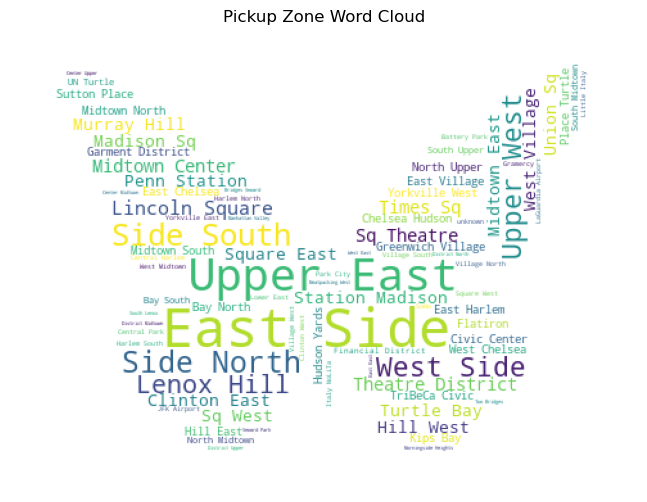

In [74]:
from PIL import Image
import numpy as np
from wordcloud import WordCloud
import matplotlib.pyplot as plt

mask = np.array(Image.open('butter.jpg').convert('L'))
mask[(mask > 200)] = 255
mask[(mask <= 200)] = 0

text = " ".join(df['PU_Zone'].astype(str))

wc = WordCloud(
    background_color='white',
    mask=mask
).generate(text)

plt.figure(figsize=(10,6))
plt.imshow(wc)
plt.axis("off")
plt.title("Pickup Zone Word Cloud")
plt.show()

From the graph, we observed that

1.The word cloud shows the most frequent pickup zones in the dataset.

2.Words that appear larger represent zones with higher number of taxi pickups.

3.Smaller words indicate zones with fewer pickups.

22. Regression plot (Trip Distance vs Fare Amount)

In [88]:
clean_df = df[
    (df['trip_distance'] >= lower_limit) &
    (df['trip_distance'] <= upper_limit) &
    (df['fare_amount'] >= lower_limit) &
    (df['fare_amount'] <= upper_limit)
]

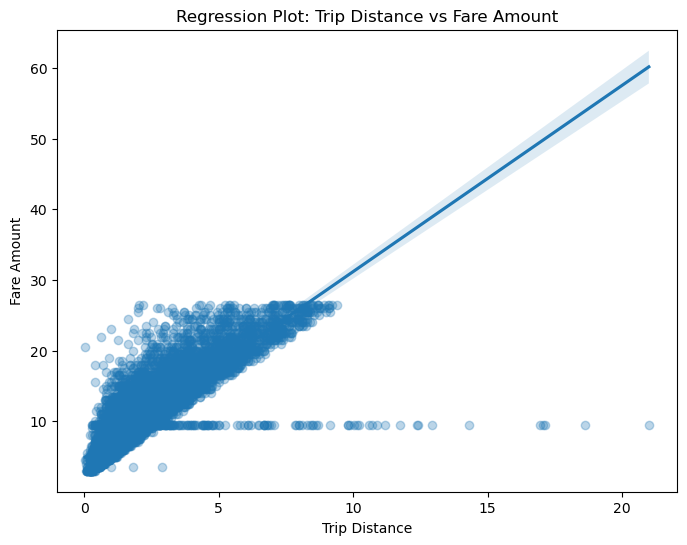

In [90]:
plt.figure(figsize=(8,6))
sns.regplot(
    data=clean_df,
    x='trip_distance',
    y='fare_amount',
    scatter_kws={"alpha":0.3}
)
plt.title("Regression Plot: Trip Distance vs Fare Amount")
plt.xlabel("Trip Distance")
plt.ylabel("Fare Amount")
plt.show()

From the graph,we can observe that 

1.The plot shows a positive relationship between trip distance and fare amount.

2.Most data points are clustered near shorter distances(0-5 miles),indicating that the majority of taxi rides are short trips.

3.The triangular spread of points suggests that fare variability increases slightly with distance due to factors like tolls,waiting time,or traffic conditions.

23. Regression plot (Trip Distance vs Duration)

In [92]:
clean_df = df[
    (df['trip_distance'] >= lower_limit) &
    (df['trip_distance'] <= upper_limit) &
    (df['trip_duration_minutes'])
]

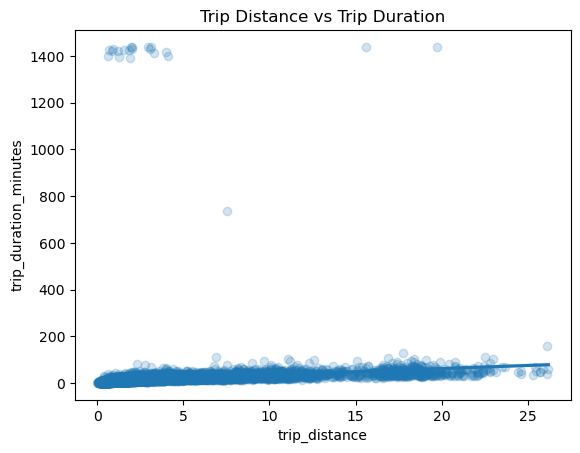

In [93]:
sns.regplot(
    data=clean_df,
    x="trip_distance",
    y="trip_duration_minutes",
    scatter_kws={"alpha":0.2}
)

plt.title("Trip Distance vs Trip Duration")
plt.show()

From the graph,we conclude that 

1.The plot shows a positive relationship between trip distance and trip duration,meaning lower trips 
generally takes more time.

2.The spread of points indicates significant variability in duration for similar distances.

3.Most trips are concentrated at short distances with relatively low travel times,again indicating that the majority of rides are short trips.